# RQ2 Notebook 08 - Lifecycle-Aware Downstream Exposure Burden

This notebook measures downstream exposure burden using an RQ1-aligned lifecycle-aware exposure start. Unlike the post-disclosure burden in notebook 05, this burden starts at the lifecycle event that defines downstream exposure for each pattern.

Pattern-specific start:

| Pattern | Start event | Rationale |
|---|---|---|
| S1 | Release | Fixed release exists before disclosure and no prior public report exists. |
| S2 | Disclosure | Vulnerability is publicly disclosed before fixed release. |
| S3 | Disclosure | Vulnerability is publicly disclosed before fix and release. |
| T1/T2/T3/T5 | Report | Transparent reporting is the RQ1 reporting signal used for downstream exposure. |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUT = Path('../../data/rq2')
MASTER = OUT / 'rq2_master_pairwise.csv'

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 80)

master = pd.read_csv(MASTER)
for c in ['adoption_date', 'report_date', 'fix_date', 'release_date', 'disclosure_date']:
    master[c] = pd.to_datetime(master[c], errors='coerce')

print(f'pairs: {len(master):,}')
print(f'CVEs : {master.CVE.nunique():,}')
print(f'repos: {master.downstream_repo.nunique():,}')
display(master.head())

pairs: 1,677
CVEs : 191
repos: 742


,CVE,upstream_GA,downstream_GA,downstream_repo,commit_url,adoption_date,commit_n_CVEs,class,pattern,original_pattern,gad_reclassified,severity,cvss,cwe,report_date,fix_date,release_date,disclosure_date,delay_report,delay_fix,delay_release,delay_disclosure,mitigation_stage,disclosure_year,dependents,downstream_usage_num,downstream_loc,downstream_class_num,upstream_stars_at_fix
0,CVE-2021-37714,org.jsoup:jsoup,com.github.btheu.estivate:estivate,btheu/estivate,https://github.com/btheu/estivate/commit/22adf...,2021-12-03 15:44:15,1,Transparent,T1,T1,False,Medium,5.0,CWE-248;CWE-835,2021-08-15 02:25:46,2021-08-15 12:31:12,2021-08-15 15:39:15,2021-08-18,110.554502,110.134062,110.003472,107.655729,After Disclosure,2021,244,0,3801.0,102.0,8521.0
1,CVE-2021-37714,org.jsoup:jsoup,com.jcabi:jcabi-http,jcabi/jcabi-http,https://github.com/jcabi/jcabi-http/commit/1a2...,2021-08-16 23:00:43,1,Transparent,T1,T1,False,Medium,5.0,CWE-248;CWE-835,2021-08-15 02:25:46,2021-08-15 12:31:12,2021-08-15 15:39:15,2021-08-18,1.857604,1.437164,1.306574,-1.041169,Release->Disclosure,2021,244,0,3957.5,89.5,8521.0
2,CVE-2021-37714,org.jsoup:jsoup,in.ashwanthkumar:gocd-java-client,ashwanthkumar/gocd-java-client,https://github.com/ashwanthkumar/gocd-java-cli...,2021-09-30 23:03:50,1,Transparent,T1,T1,False,Medium,5.0,CWE-248;CWE-835,2021-08-15 02:25:46,2021-08-15 12:31:12,2021-08-15 15:39:15,2021-08-18,46.859769,46.439329,46.308738,43.960995,After Disclosure,2021,244,0,1339.5,27.0,8521.0
3,CVE-2021-37714,org.jsoup:jsoup,tech.grasshopper:pdfextentreporter,grasshopper7/pdfextentreporter,https://github.com/grasshopper7/pdfextentrepor...,2022-03-01 12:31:07,1,Transparent,T1,T1,False,Medium,5.0,CWE-248;CWE-835,2021-08-15 02:25:46,2021-08-15 12:31:12,2021-08-15 15:39:15,2021-08-18,198.420382,197.999942,197.869352,195.521609,After Disclosure,2021,244,0,10912.0,203.0,8521.0
4,CVE-2021-37714,org.jsoup:jsoup,de.trustable.ca3s.core:ca-3-s,kuehne-trustable-de/ca3sCore,https://github.com/kuehne-trustable-de/ca3sCor...,2021-08-23 21:32:03,1,Transparent,T1,T1,False,Medium,5.0,CWE-248;CWE-835,2021-08-15 02:25:46,2021-08-15 12:31:12,2021-08-15 15:39:15,2021-08-18,8.796030,8.375590,8.245000,5.897257,After Disclosure,2021,244,0,35874.0,453.0,8521.0


## Step 1 - Assign Lifecycle-Aware Burden Start

In [2]:
START_EVENT_BY_PATTERN = {
    'S1': 'release',
    'S2': 'disclosure',
    'S3': 'disclosure',
    'T1': 'report',
    'T2': 'report',
    'T3': 'report',
    'T5': 'report',
}

DATE_COL_BY_EVENT = {
    'release': 'release_date',
    'disclosure': 'disclosure_date',
    'report': 'report_date',
}

def start_event(pattern):
    return START_EVENT_BY_PATTERN.get(pattern)

def start_date(row):
    event = start_event(row.pattern)
    if event is None:
        return pd.NaT
    return row[DATE_COL_BY_EVENT[event]]

master['lifecycle_burden_start_event'] = master.pattern.map(START_EVENT_BY_PATTERN)
master['lifecycle_burden_start_date'] = master.apply(start_date, axis=1)
master['lifecycle_burden_days_raw'] = (
    master.adoption_date - master.lifecycle_burden_start_date
).dt.total_seconds() / 86400
master['lifecycle_burden_days'] = master.lifecycle_burden_days_raw.clip(lower=0)

mapping = (
    master.drop_duplicates('pattern')
    [['pattern', 'class', 'lifecycle_burden_start_event']]
    .sort_values('pattern')
    .reset_index(drop=True)
)
display(mapping)

checks = pd.DataFrame([
    {'Check': 'No missing start event', 'Value': int(master.lifecycle_burden_start_event.isna().sum())},
    {'Check': 'No missing start date', 'Value': int(master.lifecycle_burden_start_date.isna().sum())},
    {'Check': 'Raw burden below 0', 'Value': int((master.lifecycle_burden_days_raw < 0).sum())},
])
display(checks)

if checks.loc[checks.Check.eq('No missing start event'), 'Value'].iloc[0] != 0:
    raise ValueError('Some patterns do not have a lifecycle-aware burden start event.')
if checks.loc[checks.Check.eq('No missing start date'), 'Value'].iloc[0] != 0:
    raise ValueError('Some rows do not have a lifecycle-aware burden start date.')

,pattern,class,lifecycle_burden_start_event
0,S1,Silent,release
1,S2,Silent,disclosure
2,S3,Silent,disclosure
3,T1,Transparent,report
4,T2,Transparent,report
5,T3,Transparent,report
6,T5,Transparent,report


,Check,Value
0,No missing start event,0
1,No missing start date,0
2,Raw burden below 0,7


## T17 - Lifecycle-Aware Burden By Pattern

In [3]:
PATTERN_ORDER = ['S1', 'S2', 'S3', 'T1', 'T2', 'T3', 'T5']

def med_iqr(series):
    q1, med, q3 = series.quantile([0.25, 0.5, 0.75])
    return f'{med:.0f} [{q1:.0f}, {q3:.0f}]'

rows = []
for pattern in PATTERN_ORDER:
    sub = master[master.pattern.eq(pattern)]
    if sub.empty:
        continue
    burden = sub.lifecycle_burden_days
    rows.append({
        'Pattern': pattern,
        'Class': sub['class'].iloc[0],
        'Start event': sub.lifecycle_burden_start_event.iloc[0],
        'CVEs': sub.CVE.nunique(),
        'Pairs': len(sub),
        'Median days [IQR]': med_iqr(burden),
        'Lifecycle-aware burden': burden.sum(),
        'Burden per pair': burden.mean(),
    })

T17 = pd.DataFrame(rows)
TOTAL_LIFECYCLE_BURDEN = T17['Lifecycle-aware burden'].sum()
T17['% of total burden'] = 100 * T17['Lifecycle-aware burden'] / TOTAL_LIFECYCLE_BURDEN
T17_display = T17.copy()
for col in ['Lifecycle-aware burden', 'Burden per pair', '% of total burden']:
    T17_display[col] = T17_display[col].round(1)
display(T17_display)
print(f'total lifecycle-aware burden: {TOTAL_LIFECYCLE_BURDEN:,.1f} downstream-days')
print(f'total lifecycle-aware burden: {TOTAL_LIFECYCLE_BURDEN / 365:,.1f} project-years')

,Pattern,Class,Start event,CVEs,Pairs,Median days [IQR],Lifecycle-aware burden,Burden per pair,% of total burden
0,S1,Silent,release,95,1012,"91 [15, 389]",332689.8,328.7,63.1
1,S2,Silent,disclosure,6,68,"111 [45, 290]",18051.0,265.5,3.4
2,S3,Silent,disclosure,4,20,"127 [119, 253]",4554.8,227.7,0.9
3,T1,Transparent,report,75,521,"133 [46, 339]",148849.1,285.7,28.2
4,T2,Transparent,report,6,34,"203 [74, 715]",15902.7,467.7,3.0
5,T3,Transparent,report,4,21,"119 [65, 410]",6983.3,332.5,1.3
6,T5,Transparent,report,1,1,"89 [89, 89]",88.9,88.9,0.0


total lifecycle-aware burden: 527,119.6 downstream-days
total lifecycle-aware burden: 1,444.2 project-years


## T18 - Lifecycle-Aware Burden By Class

In [4]:
T18 = (
    master.groupby('class')
    .agg(
        CVEs=('CVE', 'nunique'),
        Pairs=('CVE', 'size'),
        **{'Median days': ('lifecycle_burden_days', 'median'),
           'Lifecycle-aware burden': ('lifecycle_burden_days', 'sum'),
           'Burden per pair': ('lifecycle_burden_days', 'mean')}
    )
    .reset_index()
    .rename(columns={'class': 'Class'})
)
T18['% of total burden'] = 100 * T18['Lifecycle-aware burden'] / TOTAL_LIFECYCLE_BURDEN
T18_display = T18.copy()
for col in ['Median days', 'Lifecycle-aware burden', 'Burden per pair', '% of total burden']:
    T18_display[col] = T18_display[col].round(1)
display(T18_display)

,Class,CVEs,Pairs,Median days,Lifecycle-aware burden,Burden per pair,% of total burden
0,Silent,105,1100,96.7,355295.6,323.0,67.4
1,Transparent,86,577,133.4,171824.0,297.8,32.6


## T19 - Top CVEs By Lifecycle-Aware Burden

In [5]:
cve_burden = (
    master.groupby('CVE')
    .agg(
        pairs=('CVE', 'size'),
        lifecycle_aware_burden=('lifecycle_burden_days', 'sum'),
        median_lifecycle_burden=('lifecycle_burden_days', 'median'),
        burden_per_pair=('lifecycle_burden_days', 'mean'),
    )
    .reset_index()
)
meta = master.drop_duplicates('CVE')[
    ['CVE', 'class', 'pattern', 'severity', 'dependents', 'lifecycle_burden_start_event']
]
cve_burden = cve_burden.merge(meta, on='CVE', how='left')
cve_burden['% of total burden'] = 100 * cve_burden.lifecycle_aware_burden / TOTAL_LIFECYCLE_BURDEN

T19 = cve_burden.nlargest(15, 'lifecycle_aware_burden')[
    ['CVE', 'severity', 'class', 'pattern', 'lifecycle_burden_start_event',
     'dependents', 'pairs', 'median_lifecycle_burden', 'lifecycle_aware_burden',
     'burden_per_pair', '% of total burden']
].copy()

T19_display = T19.copy()
for col in ['median_lifecycle_burden', 'lifecycle_aware_burden', 'burden_per_pair', '% of total burden']:
    T19_display[col] = T19_display[col].round(1)
display(T19_display)

,CVE,severity,class,pattern,lifecycle_burden_start_event,dependents,pairs,median_lifecycle_burden,lifecycle_aware_burden,burden_per_pair,% of total burden
49,CVE-2017-1000487,High,Silent,S1,release,248,12,2164.7,26020.1,2168.3,4.9
4,CVE-2013-6429,Medium,Silent,S1,release,185,19,596.3,16423.6,864.4,3.1
1,CVE-2011-2894,Medium,Silent,S1,release,185,20,335.2,14817.4,740.9,2.8
9,CVE-2014-3578,Medium,Silent,S1,release,185,14,752.5,13862.8,990.2,2.6
22,CVE-2016-1000339,Medium,Silent,S1,release,155,13,893.7,13213.0,1016.4,2.5
23,CVE-2016-1000341,Medium,Silent,S1,release,155,13,893.7,13213.0,1016.4,2.5
24,CVE-2016-1000342,Medium,Silent,S1,release,155,13,893.7,13213.0,1016.4,2.5
28,CVE-2016-1000352,Medium,Silent,S1,release,155,13,893.7,13213.0,1016.4,2.5
25,CVE-2016-1000343,Medium,Silent,S1,release,155,13,893.7,13213.0,1016.4,2.5
26,CVE-2016-1000345,Medium,Silent,S1,release,155,13,893.7,13213.0,1016.4,2.5


## Save

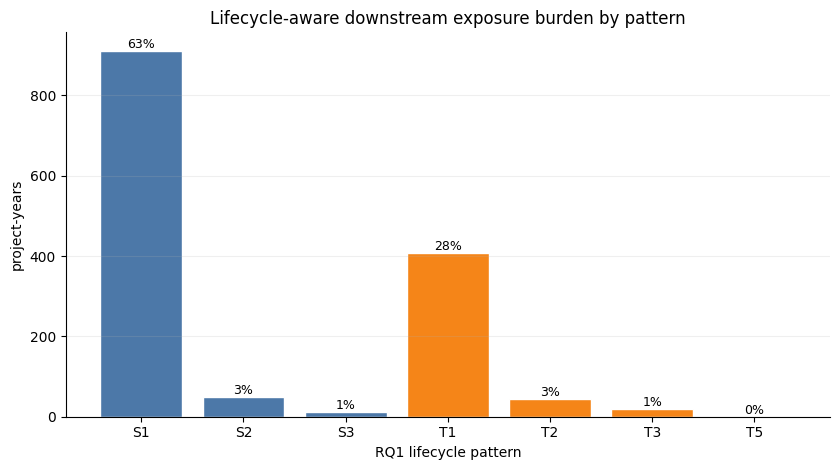

T17_lifecycle_aware_burden_by_pattern.csv
T18_lifecycle_aware_burden_by_class.csv
T19_top_cves_by_lifecycle_aware_burden.csv
rq2_lifecycle_aware_burden_per_cve.csv
rq2_master_pairwise_lifecycle_aware_burden.csv
F12_lifecycle_aware_burden_by_pattern.png


In [6]:
T17.to_csv(OUT / 'T17_lifecycle_aware_burden_by_pattern.csv', index=False)
T18.to_csv(OUT / 'T18_lifecycle_aware_burden_by_class.csv', index=False)
T19.to_csv(OUT / 'T19_top_cves_by_lifecycle_aware_burden.csv', index=False)
cve_burden.to_csv(OUT / 'rq2_lifecycle_aware_burden_per_cve.csv', index=False)
master.to_csv(OUT / 'rq2_master_pairwise_lifecycle_aware_burden.csv', index=False)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
plot = T17.copy()
colors = plot['Class'].map({'Silent': '#4c78a8', 'Transparent': '#f58518'}).fillna('#777777')
ax.bar(plot['Pattern'], plot['Lifecycle-aware burden'] / 365, color=colors, edgecolor='white')
ax.set_ylabel('project-years')
ax.set_xlabel('RQ1 lifecycle pattern')
ax.set_title('Lifecycle-aware downstream exposure burden by pattern')
for i, r in plot.iterrows():
    ax.text(i, r['Lifecycle-aware burden'] / 365, f"{r['% of total burden']:.0f}%", ha='center', va='bottom', fontsize=9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', alpha=0.2)
fig.tight_layout()
fig.savefig(OUT / 'F12_lifecycle_aware_burden_by_pattern.png', dpi=200, bbox_inches='tight')
plt.show()

print('T17_lifecycle_aware_burden_by_pattern.csv')
print('T18_lifecycle_aware_burden_by_class.csv')
print('T19_top_cves_by_lifecycle_aware_burden.csv')
print('rq2_lifecycle_aware_burden_per_cve.csv')
print('rq2_master_pairwise_lifecycle_aware_burden.csv')
print('F12_lifecycle_aware_burden_by_pattern.png')